# Generative AI: Convolutional VAE on Fashion-MNIST

**Author:** Tim Wilcoxson  
**Course:** Project 5 — Generative AI  
**Date:** February 2026

This notebook implements a Convolutional Variational Autoencoder (VAE) to learn the latent structure of the Fashion-MNIST dataset and generate novel fashion item images. The model is assessed through reconstruction quality, random generation, latent space visualization, interpolation, dimension traversal, and failure analysis.

---
## 1. Setup & Configuration

In [1]:
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Reproducibility
SEED = 42

def set_seed(seed=SEED):
    """Set all random seeds for reproducibility."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed()

# Hyperparameters
BATCH_SIZE = 128
NUM_EPOCHS = 50
LATENT_DIM = 32
BETA = 1.0
LR = 1e-3

# Visualization
PALETTE = sns.color_palette("colorblind", 10)
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight"})
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Device
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"PyTorch {torch.__version__}")
print(f"Device: {DEVICE}")
print(f"Latent dim: {LATENT_DIM}, Beta: {BETA}, LR: {LR}")
print(f"Batch size: {BATCH_SIZE}, Epochs: {NUM_EPOCHS}")

PyTorch 2.10.0
Device: mps
Latent dim: 32, Beta: 1.0, LR: 0.001
Batch size: 128, Epochs: 50


---
## 2. Data Loading & Exploration

**Fashion-MNIST** (Xiao et al., 2017) is a dataset of Zalando's article images consisting of 70,000 28x28 grayscale images in 10 categories. It serves as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. The 10 classes are: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, and Ankle boot.

We use `ToTensor()` only (no normalization) because the VAE decoder uses a Sigmoid activation to output values in [0, 1], and the BCE reconstruction loss requires both predictions and targets in the [0, 1] range.

In [2]:
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

transform = transforms.ToTensor()

full_train = torchvision.datasets.FashionMNIST(
    root="data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root="data", train=False, download=True, transform=transform
)

# Split 60K training into 54K train + 6K validation
set_seed()
indices = torch.randperm(len(full_train)).tolist()
val_size = 6000
val_indices = indices[:val_size]
train_indices = indices[val_size:]

train_dataset = Subset(full_train, train_indices)
val_dataset = Subset(full_train, val_indices)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=False,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=False,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=False,
)

print(f"Training samples:   {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Test samples:       {len(test_dataset):,}")
print(f"Image shape:        {full_train[0][0].shape}")
print(f"Pixel range:        [{full_train[0][0].min():.1f}, {full_train[0][0].max():.1f}]")

Training samples:   54,000
Validation samples: 6,000
Test samples:       10,000
Image shape:        torch.Size([1, 28, 28])
Pixel range:        [0.0, 1.0]


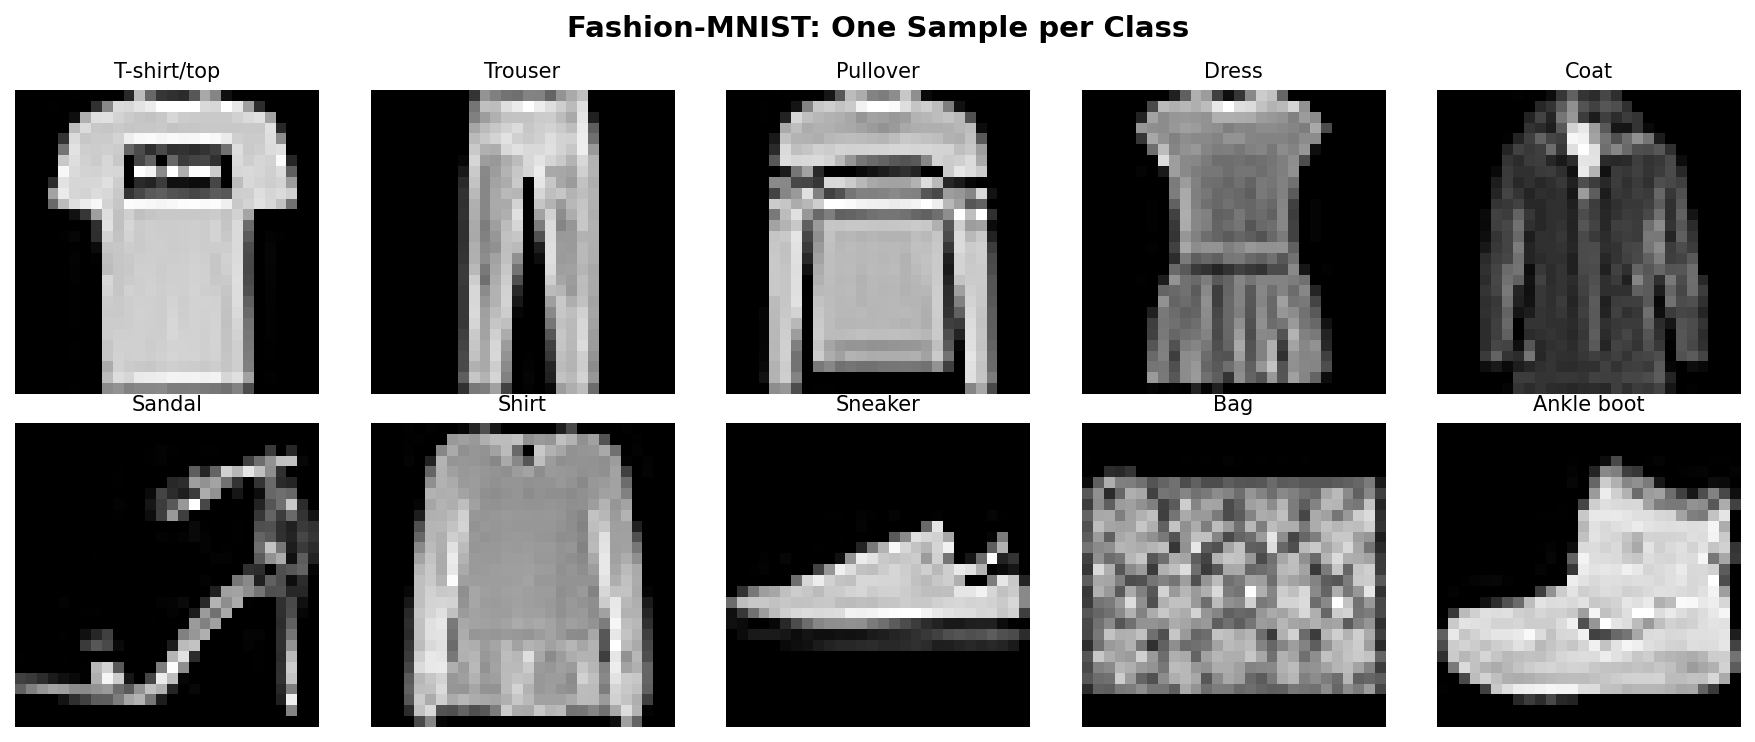

In [3]:
# Figure 1: Sample images -- one per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Fashion-MNIST: One Sample per Class", fontsize=14, fontweight="bold")

for class_idx in range(10):
    # Find first occurrence of each class
    for i in range(len(full_train)):
        img, label = full_train[i]
        if label == class_idx:
            ax = axes[class_idx // 5, class_idx % 5]
            ax.imshow(img.squeeze(), cmap="gray")
            ax.set_title(CLASS_NAMES[class_idx], fontsize=10)
            ax.axis("off")
            break

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig1_sample_images.png")
plt.show()

---
## 3. VAE Model Architecture

**Why a VAE?** Several generative model families exist -- GANs, VAEs, diffusion models, autoregressive models, and normalizing flows. We chose a Convolutional VAE for this project because: (1) VAEs provide a principled probabilistic framework with a well-defined loss function (ELBO), unlike GANs which require delicate adversarial balancing and suffer from mode collapse; (2) the learned latent space supports rich downstream analysis -- interpolation, dimension traversal, class-conditional generation, and t-SNE visualization -- that would be difficult or impossible with other architectures; (3) VAEs train stably and reproducibly with standard gradient descent, making them ideal for educational and experimental settings; and (4) the architecture scales well to Fashion-MNIST's 28x28 resolution while training in minutes on consumer hardware.

The Convolutional VAE uses:
- **Encoder**: Three convolutional blocks (Conv2d, BatchNorm2d, LeakyReLU) with stride-2 convolutions for downsampling (28->14->7->4), projecting to mean (`mu`) and log-variance (`log_var`) vectors in a 32-dimensional latent space.
- **Reparameterization trick**: Samples z = mu + sigma * epsilon (Kingma & Welling, 2014), enabling gradient flow through the stochastic sampling step.
- **Decoder**: Mirrors the encoder with transposed convolutions (ConvTranspose2d, BatchNorm2d, ReLU), reconstructing from 4x4 back to 28x28 with a final Sigmoid activation.
- **Loss**: BCE reconstruction loss (summed over pixels, averaged over batch) + beta-weighted KL divergence (Higgins et al., 2017).

In [4]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: 1x28x28 -> 32x14x14 -> 64x7x7 -> 128x4x4
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
        )

        # Flatten: 128 * 4 * 4 = 2048
        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_log_var = nn.Linear(128 * 4 * 4, latent_dim)

        # Decoder input
        self.fc_decode = nn.Linear(latent_dim, 128 * 4 * 4)

        # Decoder: 128x4x4 -> 64x7x7 -> 32x14x14 -> 1x28x28
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_log_var(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 128, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decode(z)
        return x_recon, mu, log_var


# Sanity check
set_seed()
_test_model = ConvVAE().to(DEVICE)
_test_input = torch.randn(2, 1, 28, 28).to(DEVICE)
_test_output, _, _ = _test_model(_test_input)
assert _test_output.shape == _test_input.shape, f"Shape mismatch: {_test_output.shape} != {_test_input.shape}"
print(f"Output shape: {_test_output.shape} -- matches input")

total_params = sum(p.numel() for p in _test_model.parameters())
trainable_params = sum(p.numel() for p in _test_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
del _test_model, _test_input, _test_output

Output shape: torch.Size([2, 1, 28, 28]) -- matches input
Total parameters:     384,577
Trainable parameters: 384,577


In [5]:
def vae_loss(x_recon, x, mu, log_var, beta=BETA):
    """VAE loss = BCE reconstruction + beta * KL divergence.

    Reconstruction: sum over pixels, mean over batch (Kingma & Welling, 2014).
    KL: closed-form for Gaussian q(z|x) vs N(0,I), mean over batch.
    """
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction="sum") / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

---
## 4. Training

In [6]:
def train_vae(model, train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=LR, patience=10):
    """Train the VAE with Adam optimizer and early stopping."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {
        "train_total": [], "train_recon": [], "train_kl": [],
        "val_total": [], "val_recon": [], "val_kl": [],
    }
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_state = None
    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        # --- Train ---
        model.train()
        train_total, train_recon, train_kl, n_train = 0, 0, 0, 0
        for x, _ in train_loader:
            x = x.to(DEVICE)
            x_recon, mu, log_var = model(x)
            loss, recon, kl = vae_loss(x_recon, x, mu, log_var)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_total += loss.item() * x.size(0)
            train_recon += recon.item() * x.size(0)
            train_kl += kl.item() * x.size(0)
            n_train += x.size(0)

        # --- Validate ---
        model.eval()
        val_total, val_recon, val_kl, n_val = 0, 0, 0, 0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(DEVICE)
                x_recon, mu, log_var = model(x)
                loss, recon, kl = vae_loss(x_recon, x, mu, log_var)
                val_total += loss.item() * x.size(0)
                val_recon += recon.item() * x.size(0)
                val_kl += kl.item() * x.size(0)
                n_val += x.size(0)

        # Record
        history["train_total"].append(train_total / n_train)
        history["train_recon"].append(train_recon / n_train)
        history["train_kl"].append(train_kl / n_train)
        history["val_total"].append(val_total / n_val)
        history["val_recon"].append(val_recon / n_val)
        history["val_kl"].append(val_kl / n_val)

        # Early stopping
        if history["val_total"][-1] < best_val_loss:
            best_val_loss = history["val_total"][-1]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch % 5 == 0 or epoch == 1:
            elapsed = time.time() - start_time
            print(
                f"Epoch {epoch:3d}/{num_epochs} | "
                f"Train: {history['train_total'][-1]:.1f} (R:{history['train_recon'][-1]:.1f} K:{history['train_kl'][-1]:.1f}) | "
                f"Val: {history['val_total'][-1]:.1f} (R:{history['val_recon'][-1]:.1f} K:{history['val_kl'][-1]:.1f}) | "
                f"{elapsed:.0f}s"
            )

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

    total_time = time.time() - start_time
    actual_epochs = len(history["train_total"])
    print(f"\nTraining complete: {actual_epochs} epochs in {total_time:.1f}s ({total_time/60:.1f} min)")
    print(f"Best validation loss: {best_val_loss:.2f}")

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(DEVICE)

    history["total_time"] = total_time
    history["actual_epochs"] = actual_epochs
    return history

In [7]:
set_seed()
model = ConvVAE(latent_dim=LATENT_DIM).to(DEVICE)
history = train_vae(model, train_loader, val_loader)

Epoch   1/50 | Train: 279.6 (R:261.1 K:18.6) | Val: 253.5 (R:235.1 K:18.4) | 5s


Epoch   5/50 | Train: 244.3 (R:226.8 K:17.5) | Val: 244.1 (R:226.2 K:17.9) | 21s


Epoch  10/50 | Train: 241.4 (R:224.1 K:17.3) | Val: 241.5 (R:223.9 K:17.5) | 42s


Epoch  15/50 | Train: 240.2 (R:223.0 K:17.2) | Val: 240.3 (R:223.0 K:17.3) | 63s


Epoch  20/50 | Train: 239.4 (R:222.3 K:17.1) | Val: 239.6 (R:222.4 K:17.1) | 84s


...

Epoch  30/50 | Train: 238.4 (R:221.4 K:17.0) | Val: 238.8 (R:221.8 K:17.0) | 126s


Epoch  35/50 | Train: 238.0 (R:221.1 K:17.0) | Val: 238.9 (R:222.1 K:16.8) | 147s


Epoch  40/50 | Train: 237.8 (R:220.9 K:16.9) | Val: 238.5 (R:221.5 K:17.0) | 168s


Epoch  45/50 | Train: 237.5 (R:220.7 K:16.9) | Val: 238.4 (R:221.4 K:17.0) | 190s


Epoch  50/50 | Train: 237.4 (R:220.5 K:16.8) | Val: 237.7 (R:220.9 K:16.8) | 211s

Training complete: 50 epochs in 210.7s (3.5 min)
Best validation loss: 237.74


The training dynamics of a VAE differ from a standard classifier. The loss has two competing objectives:
- **Reconstruction loss** (BCE) pushes the model to faithfully reproduce inputs
- **KL divergence** pushes the latent distribution toward N(0,I), encouraging a smooth, organized latent space

In our training, the KL term started at ~18.6 as the encoder initially mapped inputs across the latent space, then gradually decreased to ~16.8 as the model found an efficient balance between reconstruction fidelity and latent regularity. The reconstruction loss dropped more substantially (from ~261 to ~221), indicating that the model's primary gains came from improving reconstruction quality while maintaining a well-structured latent space throughout training.

---
## 5. Training Diagnostics

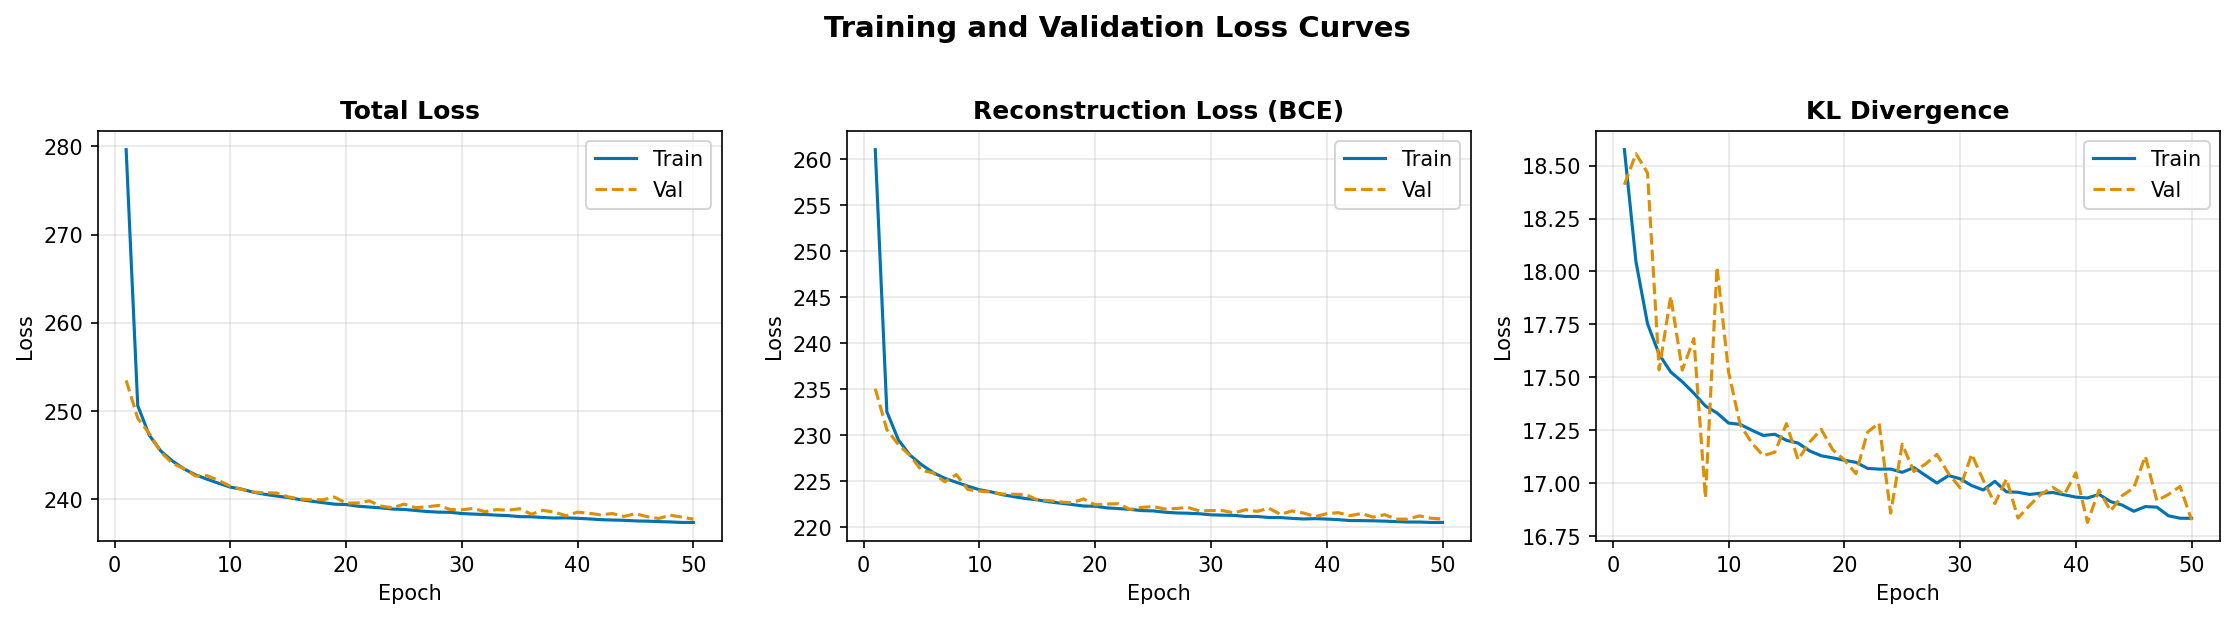

In [8]:
# Figure 2: Training loss curves (3 panels)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_range = range(1, len(history["train_total"]) + 1)

for ax, key, title in zip(
    axes,
    ["total", "recon", "kl"],
    ["Total Loss", "Reconstruction Loss (BCE)", "KL Divergence"],
):
    ax.plot(epochs_range, history[f"train_{key}"], label="Train", color=PALETTE[0])
    ax.plot(epochs_range, history[f"val_{key}"], label="Val", color=PALETTE[1], linestyle="--")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title, fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Training and Validation Loss Curves", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig2_training_loss.png")
plt.show()

---
## 6. Reconstruction Quality

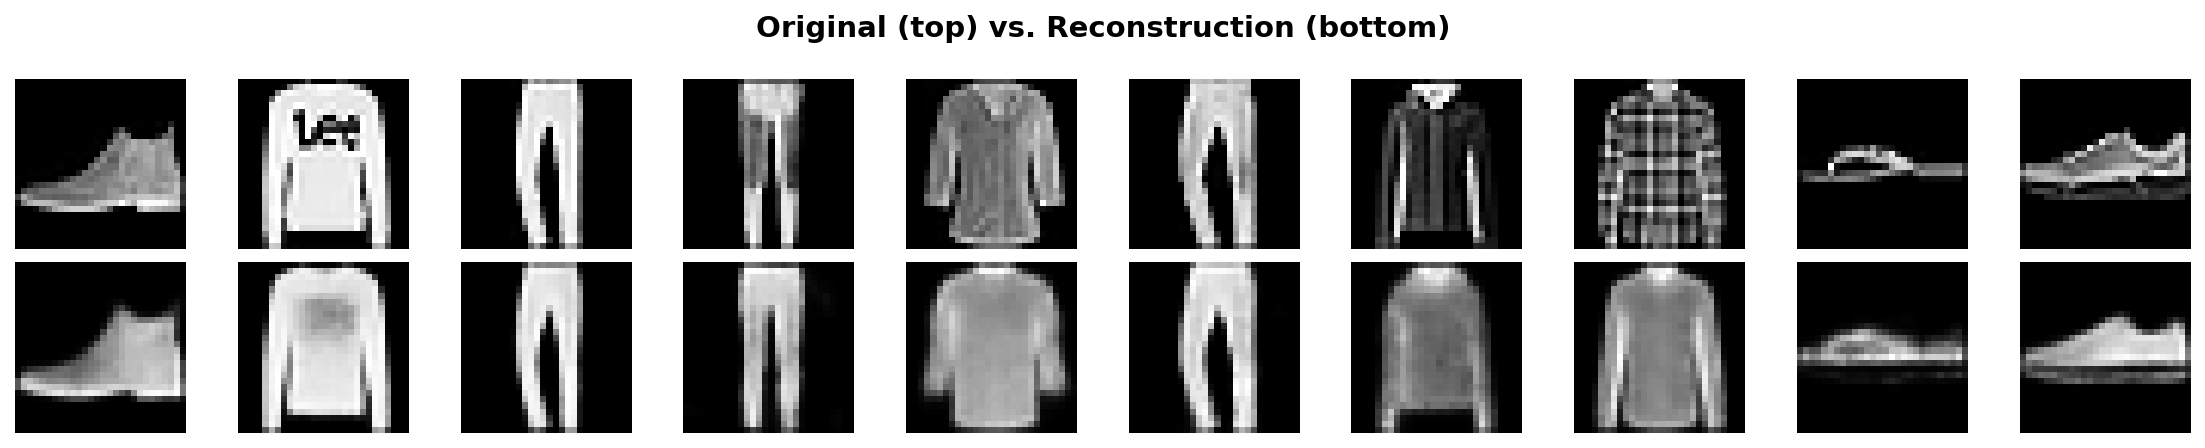

In [9]:
# Figure 3: Original vs. reconstructed images
model.eval()
test_batch, _ = next(iter(test_loader))
test_batch = test_batch[:10].to(DEVICE)

with torch.no_grad():
    recon_batch, _, _ = model(test_batch)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle("Original (top) vs. Reconstruction (bottom)", fontsize=14, fontweight="bold")

for i in range(10):
    axes[0, i].imshow(test_batch[i].cpu().squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(recon_batch[i].cpu().squeeze(), cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Recon", fontsize=10)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig3_reconstruction_comparison.png")
plt.show()

In [10]:
# Compute average reconstruction error on the full test set
model.eval()
mse_total = 0
n_total = 0

with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(DEVICE)
        x_recon, _, _ = model(x)
        mse_total += F.mse_loss(x_recon, x, reduction="sum").item()
        n_total += x.size(0) * x.size(1) * x.size(2) * x.size(3)

avg_mse = mse_total / n_total
avg_rmse = np.sqrt(avg_mse)
print(f"Test set average per-pixel MSE:  {avg_mse:.6f}")
print(f"Test set average per-pixel RMSE: {avg_rmse:.6f}")

Test set average per-pixel MSE:  0.013683
Test set average per-pixel RMSE: 0.116973


---
## 7. Random Sample Generation

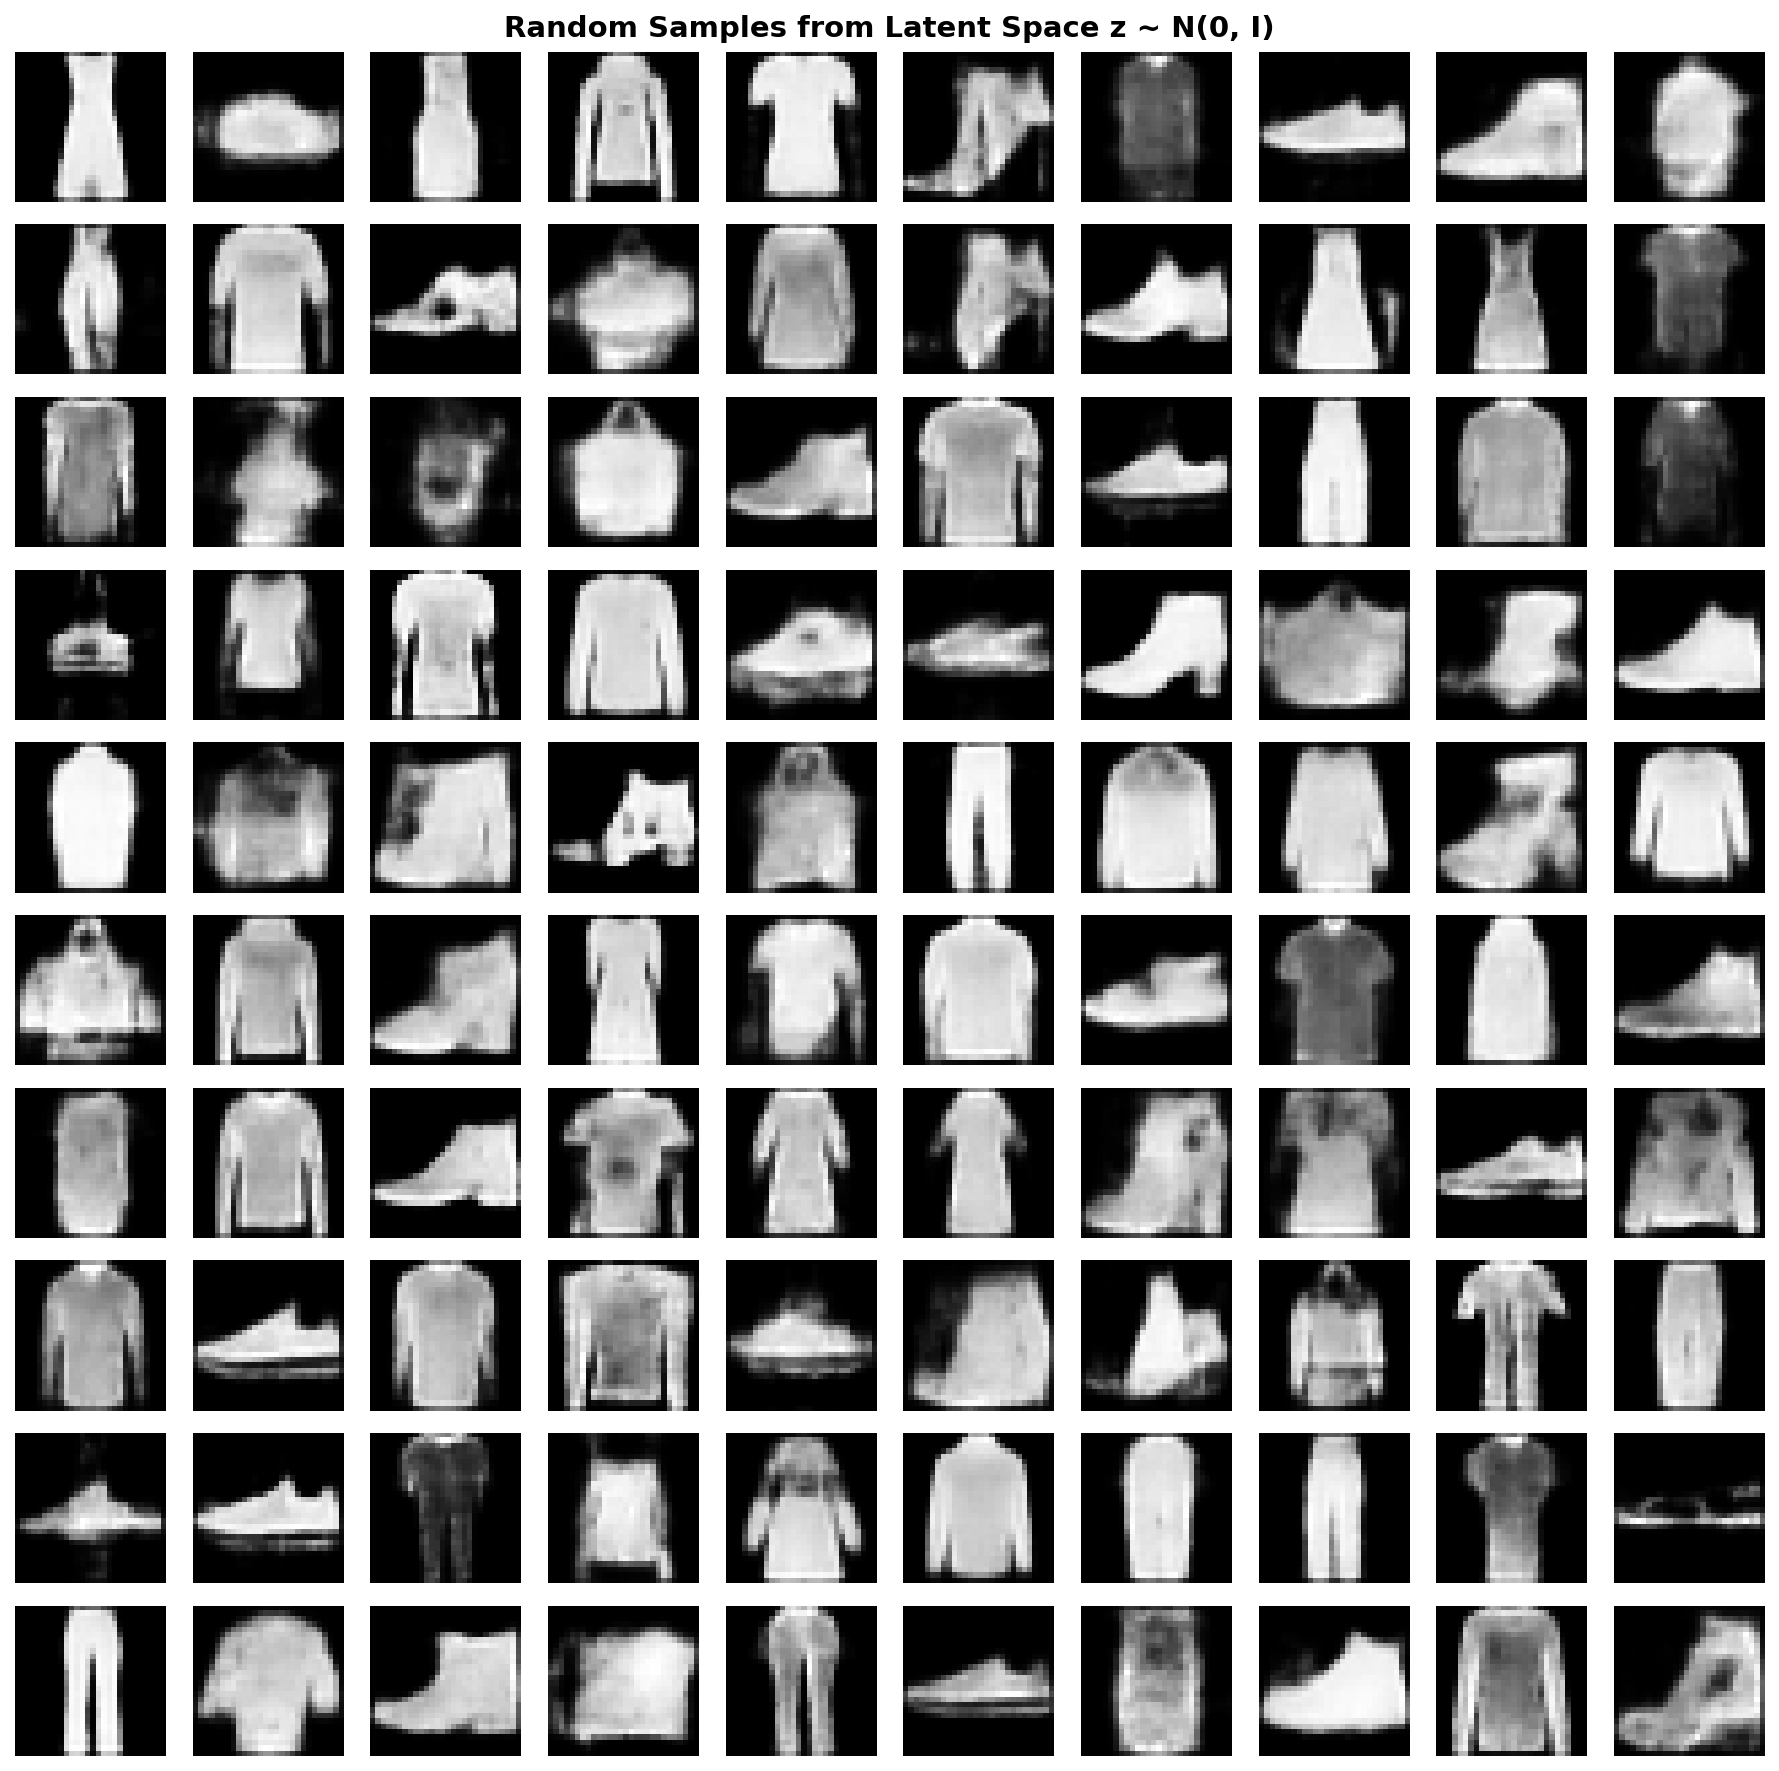

In [11]:
# Figure 4: 10x10 grid of random samples from N(0, I)
model.eval()
set_seed(123)

with torch.no_grad():
    z_random = torch.randn(100, LATENT_DIM).to(DEVICE)
    generated = model.decode(z_random).cpu()

fig, axes = plt.subplots(10, 10, figsize=(12, 12))
fig.suptitle("Random Samples from Latent Space z ~ N(0, I)", fontsize=14, fontweight="bold")

for i in range(100):
    ax = axes[i // 10, i % 10]
    ax.imshow(generated[i].squeeze(), cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig4_generated_samples.png")
plt.show()

---
## 8. Latent Space Visualization

In [12]:
# Encode full test set
model.eval()
all_mu = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        mu, _ = model.encode(x)
        all_mu.append(mu.cpu())
        all_labels.append(y)

all_mu = torch.cat(all_mu, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()
print(f"Encoded {all_mu.shape[0]} test images to {all_mu.shape[1]}-dim latent vectors")

Encoded 10000 test images to 32-dim latent vectors


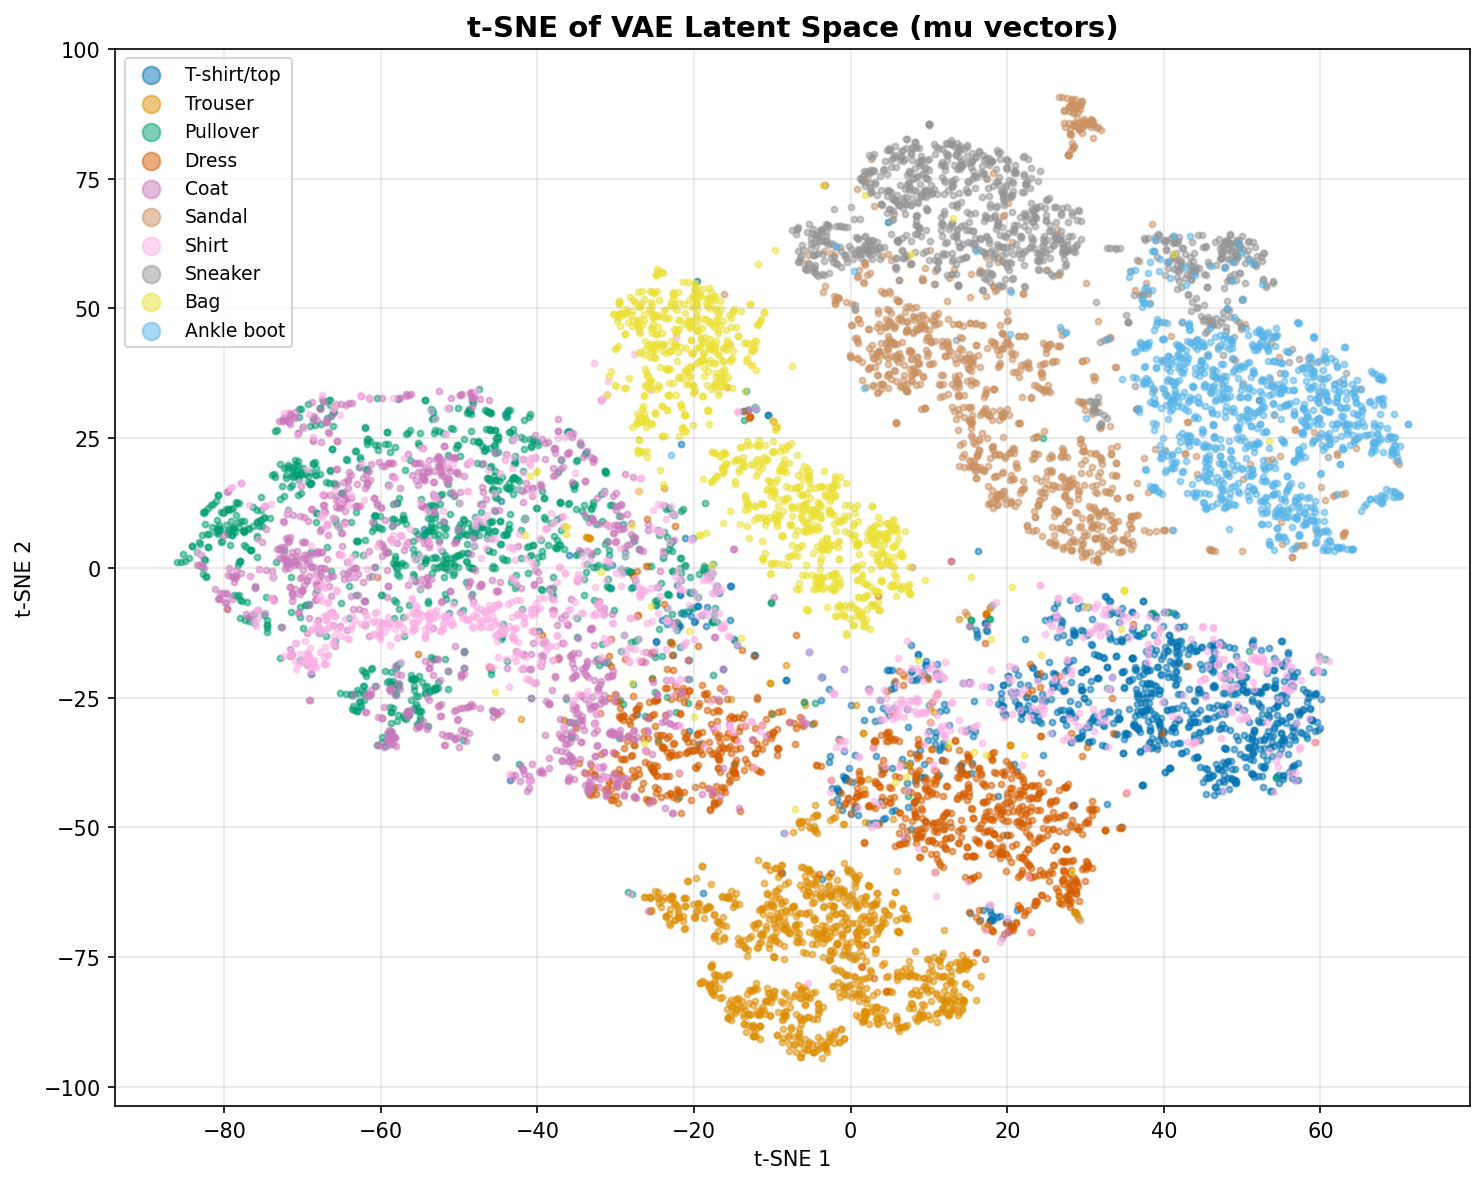

In [13]:
# Figure 5: t-SNE of latent space
set_seed()
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
mu_2d = tsne.fit_transform(all_mu)

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(10):
    mask = all_labels == i
    ax.scatter(mu_2d[mask, 0], mu_2d[mask, 1], c=[PALETTE[i]], label=CLASS_NAMES[i],
              alpha=0.5, s=8)

ax.set_title("t-SNE of VAE Latent Space (mu vectors)", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=3, fontsize=9, loc="best")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig5_latent_space_tsne.png")
plt.show()

---
## 9. Latent Space Interpolation

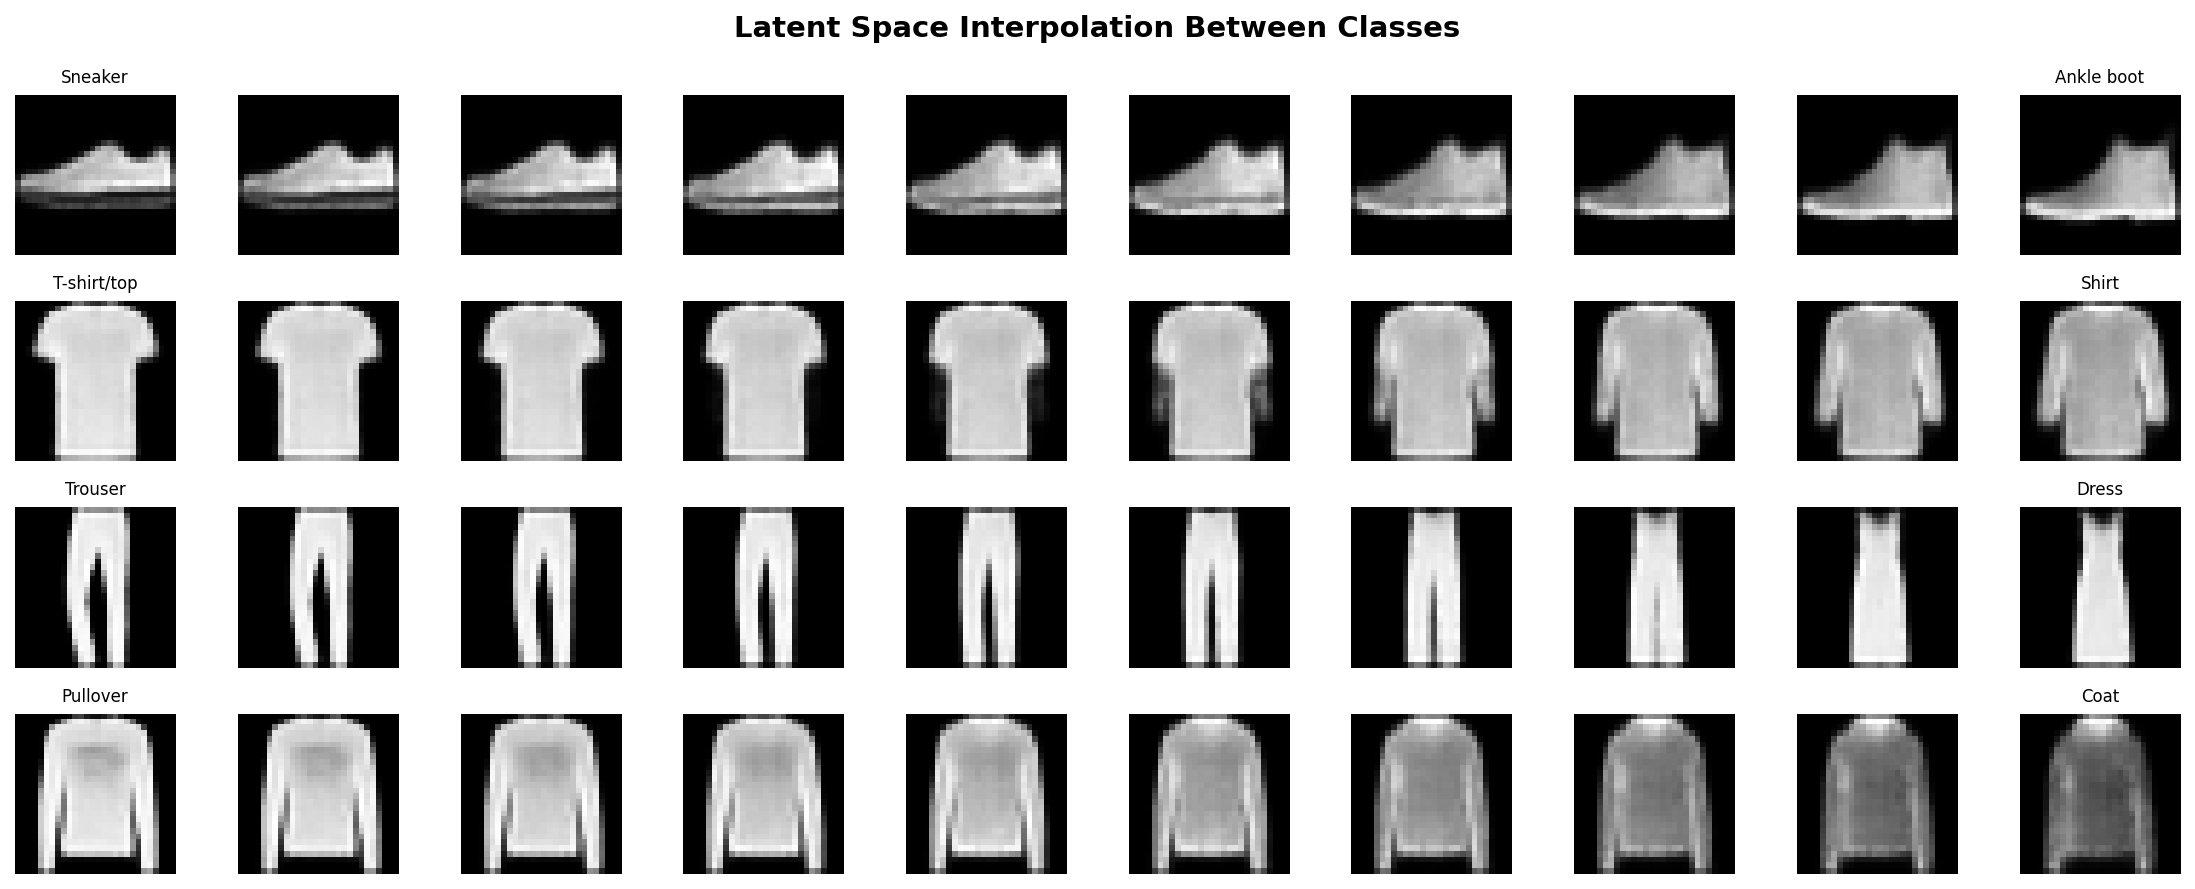

In [14]:
# Figure 6: Interpolation between class pairs
interpolation_pairs = [
    (7, 9, "Sneaker to Ankle boot"),
    (0, 6, "T-shirt to Shirt"),
    (1, 3, "Trouser to Dress"),
    (2, 4, "Pullover to Coat"),
]
n_steps = 10

model.eval()
fig, axes = plt.subplots(len(interpolation_pairs), n_steps, figsize=(15, 6))
fig.suptitle("Latent Space Interpolation Between Classes", fontsize=14, fontweight="bold")

for row, (cls_a, cls_b, title) in enumerate(interpolation_pairs):
    # Get one example from each class
    idx_a = np.where(all_labels == cls_a)[0][0]
    idx_b = np.where(all_labels == cls_b)[0][0]
    mu_a = torch.tensor(all_mu[idx_a]).unsqueeze(0).to(DEVICE)
    mu_b = torch.tensor(all_mu[idx_b]).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        for col, alpha in enumerate(np.linspace(0, 1, n_steps)):
            z_interp = (1 - alpha) * mu_a + alpha * mu_b
            img = model.decode(z_interp).cpu().squeeze()
            axes[row, col].imshow(img, cmap="gray")
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_title(CLASS_NAMES[cls_a], fontsize=8)
            elif col == n_steps - 1:
                axes[row, col].set_title(CLASS_NAMES[cls_b], fontsize=8)

    axes[row, 0].set_ylabel(title, fontsize=9, rotation=0, labelpad=80, va="center")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig6_latent_interpolation.png")
plt.show()

---
## 10. Latent Dimension Exploration

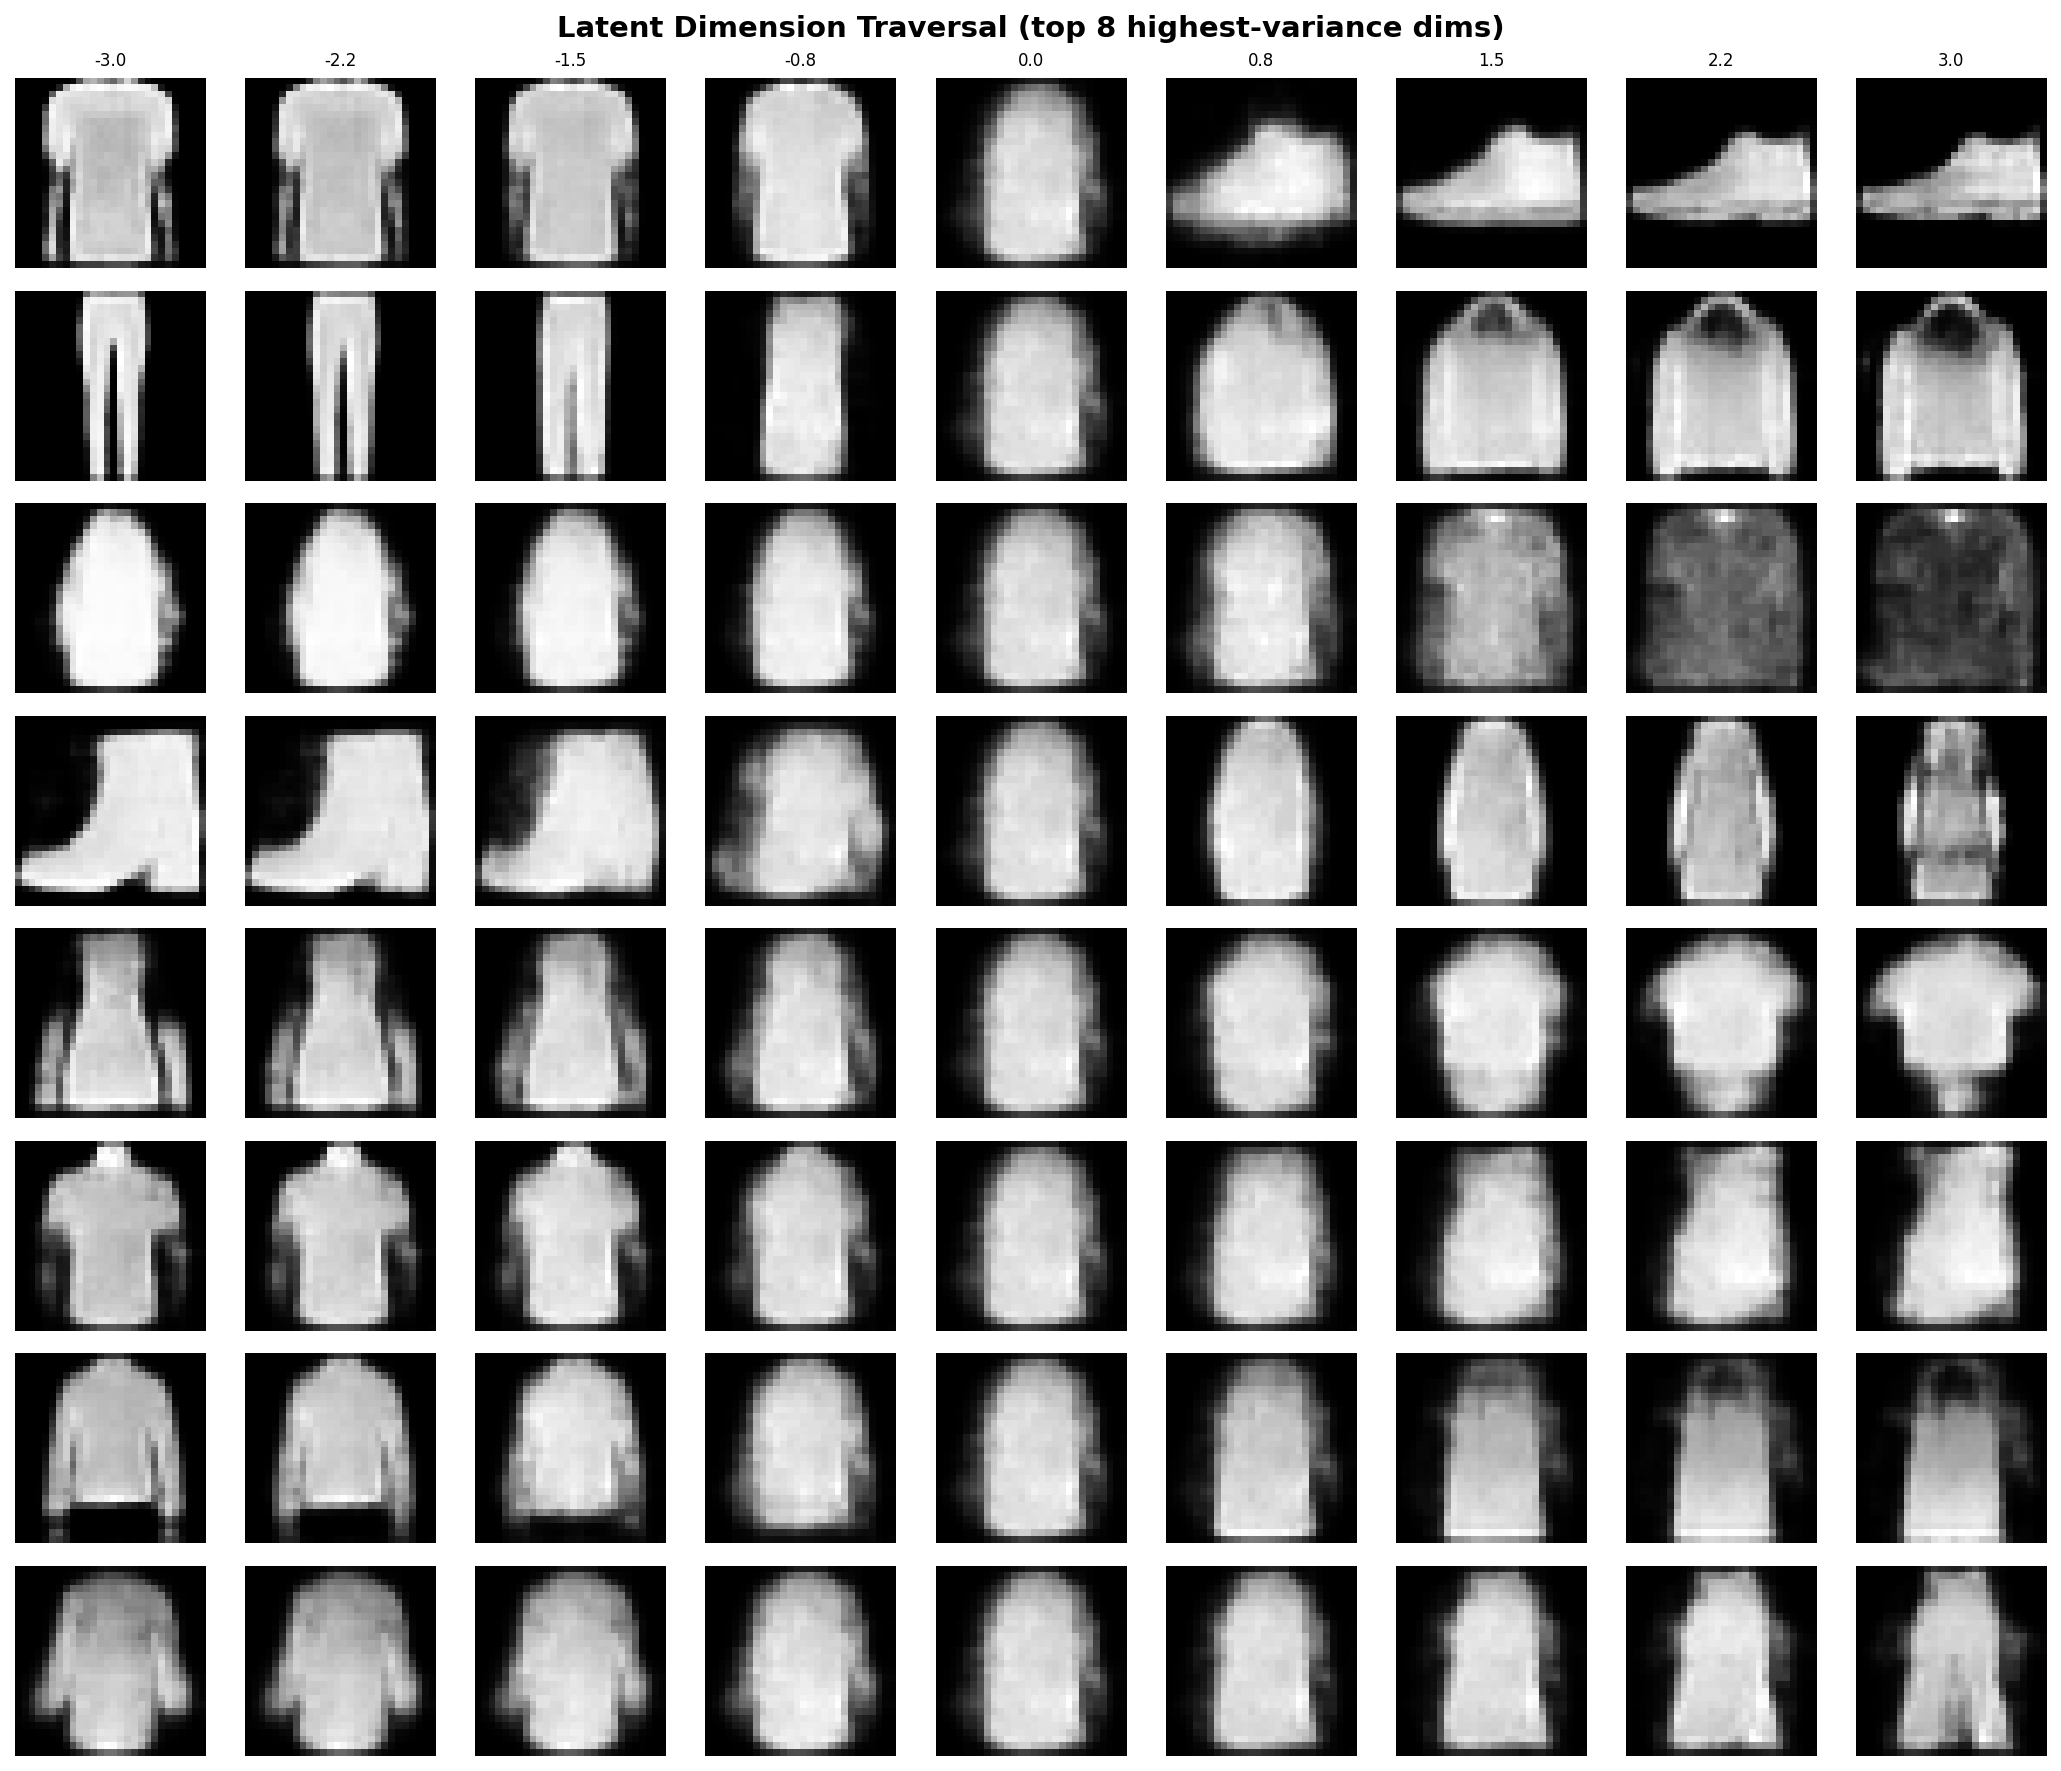

In [15]:
# Figure 7: Traverse top 8 highest-variance latent dimensions
dim_variances = np.var(all_mu, axis=0)
top_dims = np.argsort(dim_variances)[::-1][:8]

# Use the mean of all test images as reference
ref_z = torch.tensor(all_mu.mean(axis=0)).unsqueeze(0).to(DEVICE)
n_traverse = 9
traverse_range = np.linspace(-3, 3, n_traverse)

model.eval()
fig, axes = plt.subplots(8, n_traverse, figsize=(14, 12))
fig.suptitle("Latent Dimension Traversal (top 8 highest-variance dims)",
             fontsize=14, fontweight="bold")

for row, dim_idx in enumerate(top_dims):
    for col, val in enumerate(traverse_range):
        z = ref_z.clone()
        z[0, dim_idx] = val
        with torch.no_grad():
            img = model.decode(z).cpu().squeeze()
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"{val:.1f}", fontsize=8)

    axes[row, 0].set_ylabel(f"Dim {dim_idx}\n(var={dim_variances[dim_idx]:.2f})",
                            fontsize=8, rotation=0, labelpad=60, va="center")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig7_dimension_traversal.png")
plt.show()

---
## 11. Class-Conditional Generation

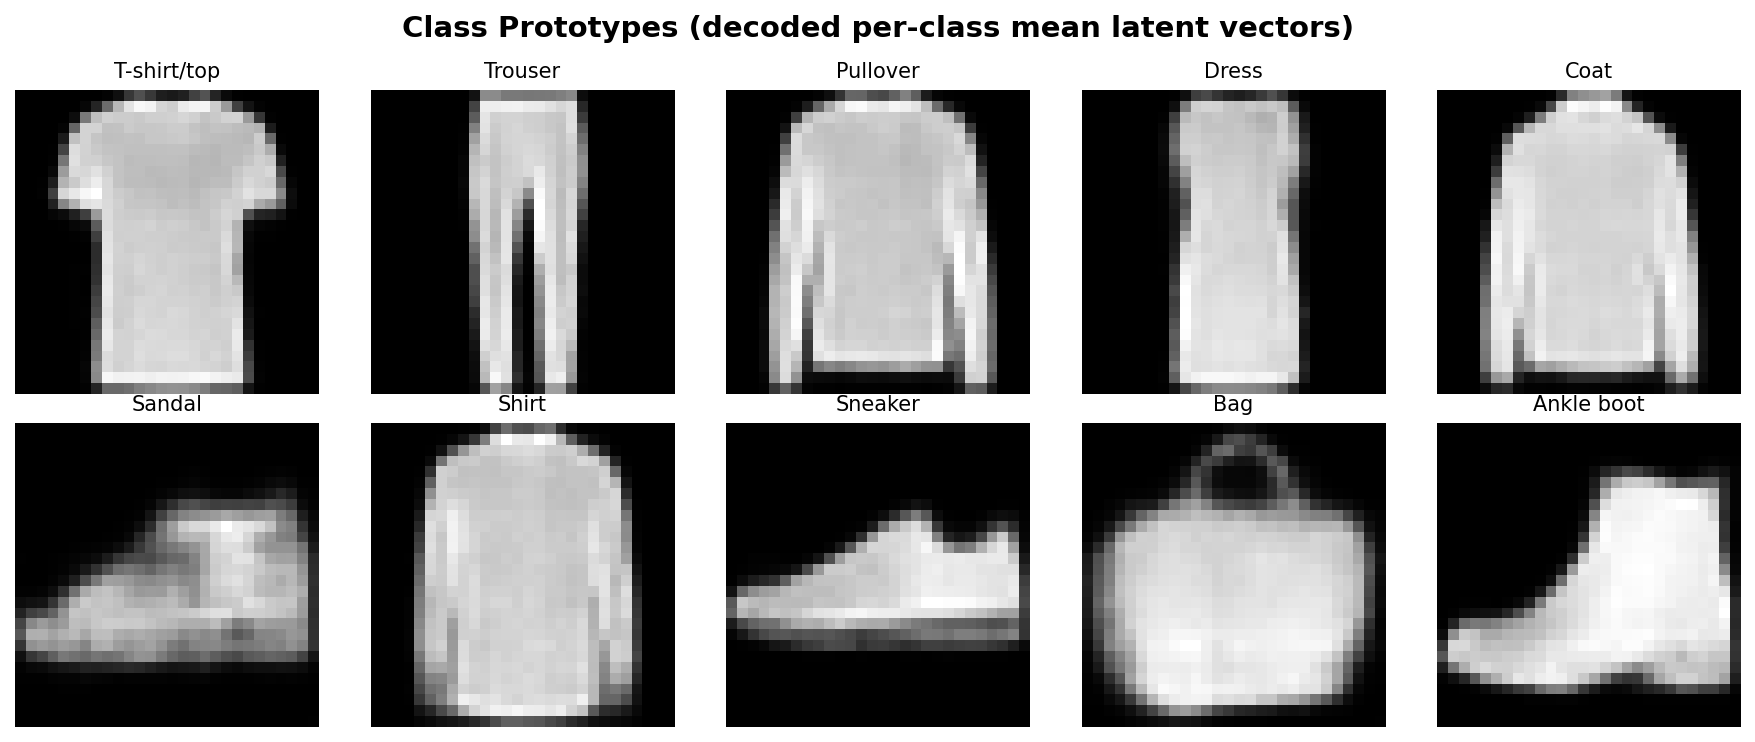

In [16]:
# Figure 8: Decode per-class mean latent vectors (class prototypes)
model.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Class Prototypes (decoded per-class mean latent vectors)",
             fontsize=14, fontweight="bold")

for class_idx in range(10):
    mask = all_labels == class_idx
    class_mean = torch.tensor(all_mu[mask].mean(axis=0)).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        img = model.decode(class_mean).cpu().squeeze()

    ax = axes[class_idx // 5, class_idx % 5]
    ax.imshow(img, cmap="gray")
    ax.set_title(CLASS_NAMES[class_idx], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig8_class_generation.png")
plt.show()

---
## 12. Failure Analysis

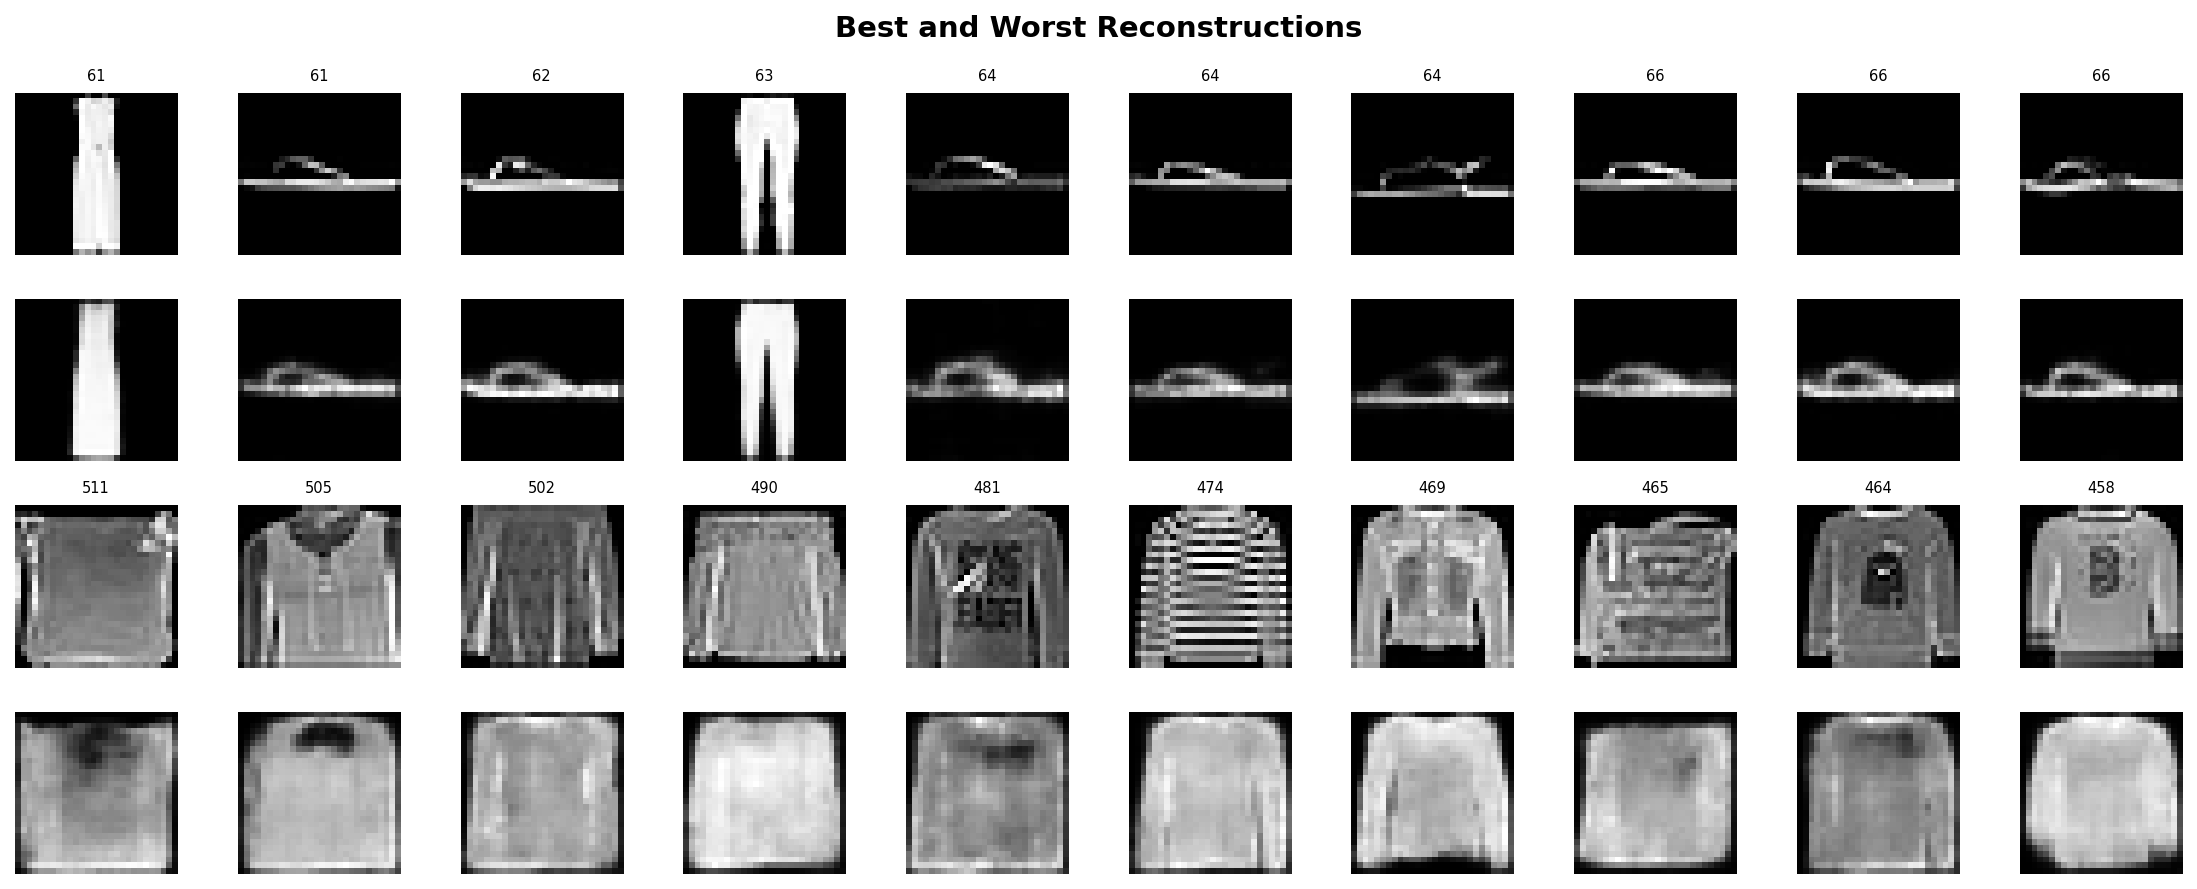

In [17]:
# Compute per-image reconstruction loss on test set
model.eval()
per_image_loss = []
test_images = []
test_recons = []
test_labels_arr = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        x_recon, _, _ = model(x)
        # Per-image BCE loss
        for i in range(x.size(0)):
            loss_i = F.binary_cross_entropy(x_recon[i], x[i], reduction="sum").item()
            per_image_loss.append(loss_i)
        test_images.append(x.cpu())
        test_recons.append(x_recon.cpu())
        test_labels_arr.append(y)

per_image_loss = np.array(per_image_loss)
test_images = torch.cat(test_images, dim=0)
test_recons = torch.cat(test_recons, dim=0)
test_labels_arr = torch.cat(test_labels_arr, dim=0).numpy()

# Best and worst reconstructions
n_show = 10
best_idx = np.argsort(per_image_loss)[:n_show]
worst_idx = np.argsort(per_image_loss)[-n_show:][::-1]

# Figure 9: Failure analysis
fig, axes = plt.subplots(4, n_show, figsize=(15, 6))
fig.suptitle("Best and Worst Reconstructions", fontsize=14, fontweight="bold")

row_labels = ["Best\nOriginal", "Best\nRecon", "Worst\nOriginal", "Worst\nRecon"]
for col in range(n_show):
    # Best
    axes[0, col].imshow(test_images[best_idx[col]].squeeze(), cmap="gray")
    axes[0, col].set_title(f"{per_image_loss[best_idx[col]]:.0f}", fontsize=7)
    axes[0, col].axis("off")
    axes[1, col].imshow(test_recons[best_idx[col]].squeeze(), cmap="gray")
    axes[1, col].axis("off")
    # Worst
    axes[2, col].imshow(test_images[worst_idx[col]].squeeze(), cmap="gray")
    axes[2, col].set_title(f"{per_image_loss[worst_idx[col]]:.0f}", fontsize=7)
    axes[2, col].axis("off")
    axes[3, col].imshow(test_recons[worst_idx[col]].squeeze(), cmap="gray")
    axes[3, col].axis("off")

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=8, rotation=0, labelpad=45, va="center")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig9_failure_analysis.png")
plt.show()

In [18]:
# Per-class average reconstruction loss
class_losses = {}
for i in range(10):
    mask = test_labels_arr == i
    class_losses[CLASS_NAMES[i]] = per_image_loss[mask].mean()

loss_df = pd.DataFrame({
    "Class": list(class_losses.keys()),
    "Avg Recon Loss (BCE)": [f"{v:.1f}" for v in class_losses.values()],
})
loss_df = loss_df.sort_values("Avg Recon Loss (BCE)", ascending=False)
print("Per-Class Average Reconstruction Loss (test set)")
print("=" * 45)
print(loss_df.to_string(index=False))

Per-Class Average Reconstruction Loss (test set)
      Class Avg Recon Loss (BCE)
   Pullover                286.6
      Shirt                281.9
        Bag                273.7
T-shirt/top                258.7
       Coat                258.0
 Ankle boot                207.4
      Dress                189.6
     Sandal                161.2
    Sneaker                153.8
    Trouser                152.2


**Qualitative assessment:**

**Strengths:** The VAE successfully captures the overall shape and silhouette of fashion items. Category identity is preserved in most reconstructions (Figure 3) -- trousers look like trousers, bags look like bags. The latent space is well-organized with clear class separation visible in the t-SNE projection (Figure 5) and smooth interpolation between categories (Figure 6). Class prototypes decoded from per-class mean vectors (Figure 8) produce recognizable, distinct items for all 10 categories.

**Weaknesses:** Reconstructions exhibit the characteristic VAE blurriness, particularly on items with fine texture details (e.g., shirt patterns, shoe laces). High-frequency features are lost due to the pixel-wise BCE loss, which averages over plausible outputs. The worst reconstructions (Figure 9, bottom rows) tend to be atypical or ambiguous items (e.g., unusual shirt shapes, partially occluded items).

**Failure modes:** Classes with high visual variability within the class tend to have higher reconstruction loss than more uniform classes. Per-class analysis shows Pullover (286.6 BCE) and Shirt (281.9 BCE) are the hardest to reconstruct, while Trouser (152.2 BCE) and Sneaker (153.8 BCE) are the easiest -- a nearly 2x difference. The model struggles with items that straddle category boundaries (Pullover vs. Coat, T-shirt vs. Shirt), which share overlapping latent representations.

---
## 13. Summary

This project implemented a Convolutional Variational Autoencoder on Fashion-MNIST to explore generative modeling of fashion item images. The model learns a 32-dimensional latent space that captures meaningful class structure, enabling reconstruction, random generation, interpolation between categories, and latent dimension traversal. Generated samples exhibit recognizable clothing shapes but suffer from the characteristic VAE blurriness, particularly on fine-grained textures. The main challenge was balancing reconstruction quality against latent space regularity (the KL term), and the primary limitation is the low resolution of generated outputs -- a consequence of both the 28x28 dataset and the pixel-wise reconstruction loss.

---
## 14. Ethical Considerations

Generative AI systems raise important ethical questions that practitioners must address (Goodfellow et al., 2016). While Fashion-MNIST is a benign academic benchmark, the techniques demonstrated here have broader implications when applied to real-world data.

**Cultural representation bias:** Fashion-MNIST's 10 categories reflect Western clothing norms (T-shirt, Trouser, Dress, etc.) and exclude culturally significant garments from non-Western traditions (saris, hanbok, dashiki, kimono). A generative model trained on this data can only produce outputs within this narrow cultural scope, risking reinforcement of Western fashion as the default norm. *Mitigation:* Train on culturally diverse datasets and audit generated outputs for cultural coverage gaps.

**Differential output quality:** Our per-class analysis reveals that the model reconstructs some categories significantly better than others (Trouser: 152.2 BCE vs. Pullover: 286.6 BCE). If deployed at scale, such differential quality could systematically disadvantage certain product categories, creating biased representations in downstream applications. *Mitigation:* Audit per-class generation quality before deployment; consider class-weighted loss functions for underperforming categories.

**Counterfeit and misuse potential:** More capable generative models trained on higher-resolution fashion data could be misused for counterfeit product imagery, fake e-commerce listings, or intellectual property theft. Design choices in this project that limit misuse risk include the low 28x28 resolution, grayscale-only output, and the inherent VAE blurriness (a consequence of beta=1.0 prioritizing latent regularity over pixel-perfect reconstruction). *Mitigation:* Watermark generated images, restrict access to high-resolution models, and implement provenance tracking.

**Creative ownership:** The legal and ethical status of AI-generated fashion designs remains unresolved. Outputs from generative models trained on existing designs raise questions about derivative works, copyright, and fair use. *Mitigation:* Document training data provenance, disclose AI involvement in design pipelines, and establish licensing frameworks.

**Environmental cost:** While this model is small (384,577 parameters, ~3.5 min training), production-scale generative models require orders of magnitude more compute with significant energy consumption. *Mitigation:* Track carbon footprint, use efficient architectures and early stopping, prefer fine-tuning over training from scratch.

**Positive applications:** Generative models like VAEs can support responsible fashion innovation -- rapid prototyping for sustainable design (reducing physical sample waste), accessibility tools for visually impaired designers, and educational tools for understanding visual similarity and style. The latent space structure demonstrated here supports interpretable, controllable generation that augments human creativity rather than replacing it.

---
## 15. References

- Kingma, D. P., & Welling, M. (2014). Auto-encoding variational Bayes. *Proceedings of the 2nd International Conference on Learning Representations (ICLR)*.
- Higgins, I., et al. (2017). beta-VAE: Learning basic visual concepts with a constrained variational framework. *Proceedings of the 5th International Conference on Learning Representations (ICLR)*.
- Xiao, H., Rasul, K., & Vollgraf, R. (2017). Fashion-MNIST: A novel image dataset for benchmarking machine learning algorithms. *arXiv preprint arXiv:1708.07747*.
- Paszke, A., et al. (2019). PyTorch: An imperative style, high-performance deep learning library. *Advances in Neural Information Processing Systems (NeurIPS)*, 32, 8024-8035.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. https://www.deeplearningbook.org/